In [8]:
import pygame
import numpy as np
import sys
import os
from PIL import Image
import io
import matplotlib.pyplot as plt
import random
import math
import heapq
import time


In [9]:

## set path and size
image_path = r"warehouse-imageLast.png"  
ROWS, COLS = 50, 50                     
SAVE_PATH = "manual_ogm.npy"

pygame.init()

# load image
# pellow for PNG image
with open(image_path, "rb") as f:
    img_bytes = f.read()

pil_img = Image.open(io.BytesIO(img_bytes)).convert("RGB")
mode = pil_img.mode
size = pil_img.size
data = pil_img.tobytes()

bg_img = pygame.image.fromstring(data, size, mode)
bg_width, bg_height = bg_img.get_size()

# make window same size as image
screen = pygame.display.set_mode((bg_width, bg_height))
pygame.display.set_caption("OGM Editor - Click to place obstacles")

# cell sizes
cell_w = bg_width / COLS
cell_h = bg_height / ROWS

#load existing grid if present, else start empty
if os.path.exists(SAVE_PATH):
    ogm = np.load(SAVE_PATH)
    print(f"Loaded existing OGM from {SAVE_PATH} with shape {ogm.shape}")
else:
    ogm = np.zeros((ROWS, COLS), dtype=np.uint8)
    print("No existing OGM found, starting with empty grid")
#function draw
def draw():
   
    screen.blit(bg_img, (0, 0))
    
    # draw obstacles
    for r in range(ROWS):
        for c in range(COLS):
            if ogm[r, c] == 1:
                rect = pygame.Rect(int(c * cell_w), int(r * cell_h),
                                   int(cell_w)+1, int(cell_h)+1)
                pygame.draw.rect(screen, (255, 0, 0), rect)
    
    # draw grid 
    grid_color = (255, 255, 255)
    for r in range(ROWS + 1):
        y = int(r * cell_h)
        pygame.draw.line(screen, grid_color, (0, y), (bg_width, y), 1)
    for c in range(COLS + 1):
        x = int(c * cell_w)
        pygame.draw.line(screen, grid_color, (x, 0), (x, bg_height), 1)
    
    pygame.display.flip()

running = True
clock = pygame.time.Clock()

while running:
    for event in pygame.event.get():
        if event.type == pygame.QUIT:
            running = False

        elif event.type == pygame.KEYDOWN:
            if event.key == pygame.K_ESCAPE:
                running = False
            elif event.key == pygame.K_s:
                # save ONLY when 's' is pressed
                np.save(SAVE_PATH, ogm)
                print(f"[S] Saved OGM to {SAVE_PATH}")
 #choose which cell
        elif event.type == pygame.MOUSEBUTTONDOWN and event.button == 1:
            mx, my = event.pos
           
            c = int(mx // cell_w)
            r = int(my // cell_h)
            if 0 <= r < ROWS and 0 <= c < COLS:
                ogm[r, c] = 1 - ogm[r, c]
                print(f"Toggled cell ({r}, {c}) -> {ogm[r, c]}")
    
    draw()
    clock.tick(60) 

pygame.quit()



Loaded existing OGM from manual_ogm.npy with shape (50, 50)


In [10]:
#print numpy
ogm = np.load("manual_ogm.npy")
print(ogm.shape)
print(ogm)

(50, 50)
[[1 1 1 ... 1 1 1]
 [1 1 1 ... 0 1 1]
 [1 1 1 ... 0 1 1]
 ...
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]]


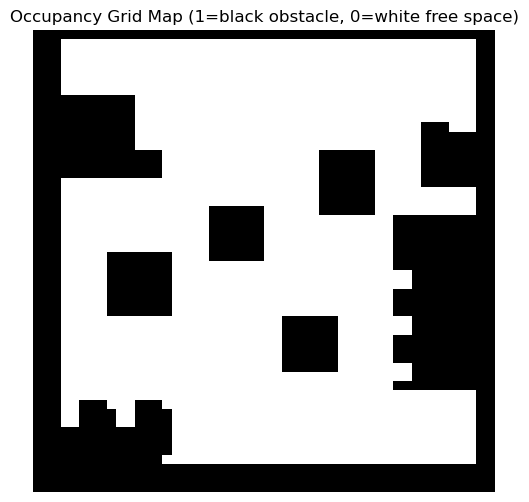

In [11]:
#turn numpy to image
ogm = np.load("manual_ogm.npy")

#  1 = black, 0 = white
plt.figure(figsize=(6,6))
plt.imshow(1 - ogm, cmap="gray", origin="upper")  
plt.title("Occupancy Grid Map (1=black obstacle, 0=white free space)")
plt.axis("off")
plt.show()

In [10]:


MANUAL_FILE = "manual_ogm.npy"    
CELL_SIZE = 12                    
MAX_STEPS = 25000                
SHOW_EVERY = 1                     
THRESHOLD = 0.6                    
RAY_RANGE = 20                    

true_map = np.load(MANUAL_FILE)    
ROWS, COLS = true_map.shape

pygame.init()
screen = pygame.display.set_mode((COLS * CELL_SIZE, ROWS * CELL_SIZE))
pygame.display.set_caption("OGM Exploration (live)")

# log-odds map 
log_odds = np.zeros((ROWS, COLS), dtype=float)

# colors
COLOR_UNKNOWN = (150, 150, 150)
COLOR_FREE    = (240, 240, 240)
COLOR_OCC     = (180, 30, 30)
COLOR_ROBOT   = (0, 200, 0)

clock = pygame.time.Clock()

class Robot:
    def __init__(self, env):
        self.env = env
        h, w = env.shape
        while True:
            r = random.randint(0, h - 1)
            c = random.randint(0, w - 1)
            if env[r, c] == 0:
                self.r = r
                self.c = c
                break
        self.orientation = random.uniform(0, 2*math.pi)

    def sense(self):
        hits = []
        angles = np.linspace(-math.pi/4, math.pi/4, 5) + self.orientation
        for ang in angles:
            for d in range(1, RAY_RANGE+1):
                rr = int(self.r + d * math.sin(ang))
                cc = int(self.c + d * math.cos(ang))
                if 0 <= rr < ROWS and 0 <= cc < COLS:
                    hits.append((rr, cc))
                    if true_map[rr, cc] == 1:
                        break
                else:
                    break
        return hits

    def move(self):
        moves = [(1,0),(-1,0),(0,1),(0,-1)]
        random.shuffle(moves)
        for dr, dc in moves:
            nr, nc = self.r + dr, self.c + dc
            if 0 <= nr < ROWS and 0 <= nc < COLS and true_map[nr, nc] == 0:
                self.r, self.c = nr, nc
                self.orientation = math.atan2(dr, dc)
                return

robot = Robot(true_map)

def inverse_sensor_model(rr, cc):
    if true_map[rr, cc] == 1:
        return 0.9
    else:
        return 0.3

def draw_current(prob_map, robot_pos):
    for r in range(ROWS):
        for c in range(COLS):
            x = c * CELL_SIZE
            y = r * CELL_SIZE
            p = prob_map[r, c]
            if p < 0.4:
                color = COLOR_FREE
            elif p > 0.6:
                color = COLOR_OCC
            else:
                color = COLOR_UNKNOWN
            pygame.draw.rect(screen, color, (x, y, CELL_SIZE, CELL_SIZE))

    rr, cc = robot_pos
    pygame.draw.rect(screen, COLOR_ROBOT,
                     (cc * CELL_SIZE, rr * CELL_SIZE, CELL_SIZE, CELL_SIZE))

    # grid
    for r in range(ROWS):
        pygame.draw.line(screen, (80, 80, 80), (0, r*CELL_SIZE), (COLS*CELL_SIZE, r*CELL_SIZE), 1)
    for c in range(COLS):
        pygame.draw.line(screen, (80, 80, 80), (c*CELL_SIZE, 0), (c*CELL_SIZE, ROWS*CELL_SIZE), 1)

    pygame.display.flip()

running = True
step = 0

try:
    while running and step < MAX_STEPS:
        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                running = False

        
        seen_cells = robot.sense()
        for (rr, cc) in seen_cells:
            p = inverse_sensor_model(rr, cc)
            l_old = log_odds[rr, cc]
            l_sensor = math.log(p / (1 - p))
            log_odds[rr, cc] = l_old + l_sensor

        # move
        robot.move()

        # for drawing
        l_clip = np.clip(log_odds, -20, 20)
        prob_map = 1 / (1 + np.exp(-l_clip))

        if step % SHOW_EVERY == 0:
            draw_current(prob_map, (robot.r, robot.c))

        step += 1
        clock.tick(60)

finally:
    l_clip = np.clip(log_odds, -20, 20)
    prob_map = 1 / (1 + np.exp(-l_clip))
    final_ogm = (prob_map > THRESHOLD).astype(np.uint8)
    np.save("explored_ogm.npy", final_ogm)
    print("Saved explored_ogm.npy with shape:", final_ogm.shape)

    pygame.quit()


Saved explored_ogm.npy with shape: (50, 50)


In [12]:
#print numpy
arr = np.load("explored_ogm.npy")
print(arr)

[[0 0 1 ... 1 1 0]
 [0 0 1 ... 0 1 0]
 [0 0 1 ... 0 1 0]
 ...
 [0 0 0 ... 1 1 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


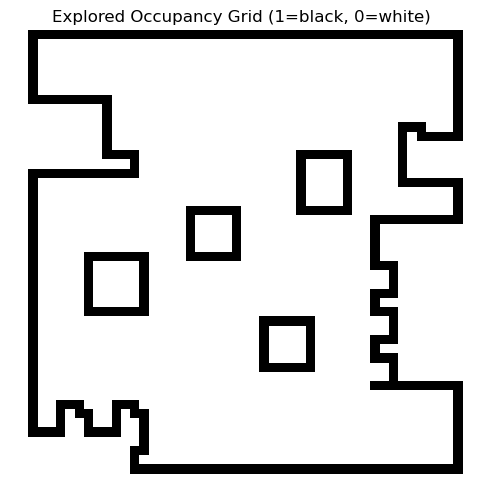

Saved as 'explored_map.png'


In [13]:
#turn numpy to image
explored_ogm = np.load("explored_ogm.npy")

plt.figure(figsize=(6,6))
plt.imshow(1 - explored_ogm, cmap="gray", origin="upper")  
plt.title("Explored Occupancy Grid (1=black, 0=white)")
plt.axis("off")
plt.show()

# Save it as an image file
img = (1 - explored_ogm) * 255   
img = img.astype(np.uint8)
Image.fromarray(img).save("explored_map.png")

print("Saved as 'explored_map.png'")

In [14]:


MAP_PATH = "explored_ogm.npy"   #  0/1 grid map
IMAGE_PATH = r"warehouse-imageLast.png"
WORKER_PATH = r"—Pngtree—cartoon construction worker pushing wheelbarrow_23076520.PNG"
SPEED = 80
WORKER_SCALE = 6.0       
OVERLAY_ALPHA = 90      

# load grid
ogm = np.load(MAP_PATH)
ROWS, COLS = ogm.shape

pygame.init()

# load background
with open(IMAGE_PATH, "rb") as f:
    img_bytes = f.read()
pil_img = Image.open(io.BytesIO(img_bytes)).convert("RGB")
bg_w, bg_h = pil_img.size
bg_surface = pygame.image.fromstring(pil_img.tobytes(), pil_img.size, pil_img.mode)

screen = pygame.display.set_mode((bg_w, bg_h))
pygame.display.set_caption("Dynamic Worker - Large Worker")

# cell sizes 
cell_w = bg_w / COLS
cell_h = bg_h / ROWS

# worker image 
worker_img = pygame.image.load(WORKER_PATH).convert_alpha()
worker_w = int(cell_w * WORKER_SCALE)
worker_h = int(cell_h * WORKER_SCALE)
worker_img = pygame.transform.smoothscale(worker_img, (worker_w, worker_h))


class Worker:
    def __init__(self, ogm_array):
        self.ogm = ogm_array
        self.r, self.c = self._random_free_cell()
        self.x = self.c * cell_w
        self.y = self.r * cell_h
        self.target_r = self.r
        self.target_c = self.c
        self.speed = SPEED

    def _random_free_cell(self):
        free = np.argwhere(self.ogm == 0)
        idx = random.randint(0, len(free) - 1)
        return tuple(free[idx])

    def pick_new_target(self):
        dirs = [(1,0),(-1,0),(0,1),(0,-1)]
        random.shuffle(dirs)
        for dr, dc in dirs:
            nr, nc = self.r + dr, self.c + dc
            if 0 <= nr < ROWS and 0 <= nc < COLS and self.ogm[nr, nc] == 0:
                self.target_r, self.target_c = nr, nc
                return
        self.target_r, self.target_c = self.r, self.c

    def update(self, dt):
        tx = self.target_c * cell_w
        ty = self.target_r * cell_h
        dx = tx - self.x
        dy = ty - self.y
        dist = math.hypot(dx, dy)

        if dist < 1:
            self.r, self.c = self.target_r, self.target_c
            self.pick_new_target()
        else:
            step = self.speed * dt
            if step > dist:
                step = dist
            if dist > 0:
                self.x += (dx / dist) * step
                self.y += (dy / dist) * step

    def draw(self, surf):
        x_off = self.x + (cell_w - worker_w) / 2
        y_off = self.y + (cell_h - worker_h) / 2
        surf.blit(worker_img, (x_off, y_off))


workers = [Worker(ogm) for _ in range(4)]

def draw():
    # Draw background
    screen.blit(bg_surface, (0, 0))

    overlay = pygame.Surface((bg_w, bg_h), pygame.SRCALPHA)
    red = (255, 0, 0, OVERLAY_ALPHA)
    for r in range(ROWS):
        for c in range(COLS):
            if ogm[r, c] == 1:
                x1 = int(c * cell_w)
                y1 = int(r * cell_h)
                x2 = int((c + 1) * cell_w)
                y2 = int((r + 1) * cell_h)
                pygame.draw.rect(overlay, red, (x1, y1, x2 - x1, y2 - y1))
    screen.blit(overlay, (0, 0))

    # draw worker
    for w in workers:
        w.draw(screen)


    pygame.display.flip()


clock = pygame.time.Clock()
running = True

while running:
    dt = clock.tick(60) / 1000.0
    for event in pygame.event.get():
        if event.type == pygame.QUIT:
            running = False
        elif event.type == pygame.KEYDOWN and event.key == pygame.K_ESCAPE:
            running = False

    for w in workers:
        w.update(dt)
        draw()

pygame.quit()


In [16]:

MAP_PATH = "manual_ogm.npy"
IMAGE_PATH = r"warehouse-imageLast.png"
ROBOT_PATH = r"—Pngtree—lovely lovely cute robot blue_3920844.png"
WORKER_PATH = r"—Pngtree—cartoon construction worker pushing wheelbarrow_23076520.PNG"
OVERLAY_ALPHA = 60
MOVE_INTERVAL = 160
ROBOT_SCALE = 4.0
WORKER_SPEED = 35
WORKER_SCALE = 4.0
NUM_WORKERS = 4
BLOCK_PAUSE_MS = 1200
WORKER_BLOCK_RADIUS = 1
ITEM_RADIUS_FACTOR = 0.7


# METRICS
total_plans = 0              
total_reroutes = 0          
total_items_picked = 0      
total_drop_visits = 0        
start_time = time.time()
last_report_time = start_time



def load_image_safe(path):
    with open(path, "rb") as f:
        b = f.read()
    pil_img = Image.open(io.BytesIO(b)).convert("RGBA")
    return pygame.image.fromstring(pil_img.tobytes(), pil_img.size, pil_img.mode)

#load map 
ogm = np.load(MAP_PATH)
ROWS, COLS = ogm.shape

pygame.init()

with open(IMAGE_PATH, "rb") as f:
    img_bytes = f.read()
pil_img = Image.open(io.BytesIO(img_bytes)).convert("RGB")
bg_w, bg_h = pil_img.size
bg_surface = pygame.image.fromstring(pil_img.tobytes(), pil_img.size, pil_img.mode)

screen = pygame.display.set_mode((bg_w, bg_h))
pygame.display.set_caption("Priority Multi-Item Pickup & Delivery (A*)")

cell_w = bg_w / COLS
cell_h = bg_h / ROWS

robot_img = load_image_safe(ROBOT_PATH)
rob_w = int(cell_w * ROBOT_SCALE)
rob_h = int(cell_h * ROBOT_SCALE)
robot_img = pygame.transform.smoothscale(robot_img, (rob_w, rob_h))

worker_img = load_image_safe(WORKER_PATH)
worker_w = int(cell_w * WORKER_SCALE)
worker_h = int(cell_h * WORKER_SCALE)
worker_img = pygame.transform.smoothscale(worker_img, (worker_w, worker_h))

# A* algorithm 
def heuristic(a, b):
    return abs(a[0] - b[0]) + abs(a[1] - b[1])

def neighbors(r, c, blocked):
    for dr, dc in [(1,0),(-1,0),(0,1),(0,-1)]:
        nr, nc = r + dr, c + dc
        if 0 <= nr < ROWS and 0 <= nc < COLS:
            if ogm[nr, nc] == 0 and (nr, nc) not in blocked:
                yield nr, nc

def astar(start, goal, blocked=None):
    if blocked is None:
        blocked = set()
    if goal in blocked:
        return None
    open_set = []
    heapq.heappush(open_set, (heuristic(start, goal), 0, start))
    came_from = {}
    g_score = {start: 0}
    while open_set:
        _, cost, current = heapq.heappop(open_set)
        if current == goal:
            path = [current]
            while current in came_from:
                current = came_from[current]
                path.append(current)
            path.reverse()
            return path
        cr, cc = current
        for nr, nc in neighbors(cr, cc, blocked):
            new_cost = cost + 1
            nxt = (nr, nc)
            if nxt not in g_score or new_cost < g_score[nxt]:
                g_score[nxt] = new_cost
                pr = new_cost + heuristic(nxt, goal)
                heapq.heappush(open_set, (pr, new_cost, nxt))
                came_from[nxt] = current
    return None

#Workers
class Worker:
    def __init__(self, grid):
        self.grid = grid
        self.r, self.c = self._random_free_cell()
        self.x = self.c * cell_w
        self.y = self.r * cell_h
        self.target_r = self.r
        self.target_c = self.c
        self.speed = WORKER_SPEED

    def _random_free_cell(self):
        free = np.argwhere(self.grid == 0)
        idx = random.randint(0, len(free)-1)
        return tuple(free[idx])

    def pick_new_target(self):
        dirs = [(1,0),(-1,0),(0,1),(0,-1)]
        random.shuffle(dirs)
        for dr, dc in dirs:
            nr, nc = self.r + dr, self.c + dc
            if 0 <= nr < ROWS and 0 <= nc < COLS and self.grid[nr, nc] == 0:
                self.target_r, self.target_c = nr, nc
                return
        self.target_r, self.target_c = self.r, self.c

    def update(self, dt):
        tx = self.target_c * cell_w
        ty = self.target_r * cell_h
        dx = tx - self.x
        dy = ty - self.y
        dist = math.hypot(dx, dy)
        if dist < 1:
            self.r, self.c = self.target_r, self.target_c
            self.pick_new_target()
        else:
            step = self.speed * dt
            if step > dist:
                step = dist
            self.x += (dx / dist) * step
            self.y += (dy / dist) * step

    def draw(self, surf):
        x_off = self.x + (cell_w - worker_w)/2
        y_off = self.y + (cell_h - worker_h)/2
        surf.blit(worker_img, (x_off, y_off))

    def current_cell(self):
        col = int(self.x // cell_w)
        row = int(self.y // cell_h)
        col = min(max(col, 0), COLS - 1)
        row = min(max(row, 0), ROWS - 1)
        return (row, col)

workers = [Worker(ogm) for _ in range(NUM_WORKERS)]

#Robot
class Robot:
    def __init__(self):
        self.r = ROWS // 2
        self.c = COLS // 2
        self.path = []
        self.last_move = pygame.time.get_ticks()
        self.stage = "idle"    
        self.current_goal = None
        self.wait_until = 0
        self.needs_reroute = False
        self.current_target_item = None  

    def set_position(self, r, c):
        self.r, self.c = r, c
        self.path = []
        self.stage = "idle"
        self.current_goal = None
        self.current_target_item = None
        self.wait_until = 0
        self.needs_reroute = False

    def set_path(self, path, stage, target_item=None):
        self.path = path if path else []
        self.stage = stage
        self.current_goal = path[-1] if path else None
        self.current_target_item = target_item
        self.needs_reroute = False
        self.wait_until = 0

    def update(self, worker_list):
        if not self.path:
            return
        now = pygame.time.get_ticks()
        if now < self.wait_until:
            return

        # worker blocking
        if len(self.path) > 1:
            nr, nc = self.path[1]
            for w in worker_list:
                wr, wc = w.current_cell()
                if abs(wr - nr) <= WORKER_BLOCK_RADIUS and abs(wc - nc) <= WORKER_BLOCK_RADIUS:
                    self.wait_until = now + BLOCK_PAUSE_MS
                    self.needs_reroute = True
                    return

        if now - self.last_move < MOVE_INTERVAL:
            return
        self.last_move = now

        if len(self.path) > 1:
            self.path.pop(0)
            self.r, self.c = self.path[0]
        else:
            # reached destination
            self.path = []
            self.current_goal = None
            if self.stage == "to_item":
                self.stage = "idle"
                self.current_target_item = None
            elif self.stage == "to_drop":
                self.stage = "idle"

    def draw(self, surf):
        x = self.c * cell_w + (cell_w - rob_w)/2
        y = self.r * cell_h + (cell_h - rob_h)/2
        surf.blit(robot_img, (x, y))

robot = Robot()

# items & drop 
items = []
drop_cell = None
env_dirty = False
current_item_priority = 3  

def pick_best_item(from_cell, items_list):
    """Pick item with highest priority; tie-break by nearest."""
    if not items_list:
        return None
    max_prio = max(it['prio'] for it in items_list)
    candidates = [it for it in items_list if it['prio'] == max_prio]
    fr, fc = from_cell
    best = None
    best_dist = 10**9
    for it in candidates:
        (ir, ic) = it['pos']
        d = abs(ir - fr) + abs(ic - fc)
        if d < best_dist:
            best_dist = d
            best = it
    return best

def draw(path_to_draw=None):
    screen.blit(bg_surface, (0, 0))

    overlay = pygame.Surface((bg_w, bg_h), pygame.SRCALPHA)
    red = (255, 0, 0, OVERLAY_ALPHA)
    for r in range(ROWS):
        for c in range(COLS):
            if ogm[r, c] == 1:
                x1 = int(c * cell_w); y1 = int(r * cell_h)
                x2 = int((c + 1) * cell_w); y2 = int((r + 1) * cell_h)
                pygame.draw.rect(overlay, red, (x1, y1, x2 - x1, y2 - y1))
    screen.blit(overlay, (0, 0))

    if path_to_draw:
        for (rr, cc) in path_to_draw:
            x1 = int(cc * cell_w); y1 = int(rr * cell_h)
            x2 = int((cc + 1) * cell_w); y2 = int((rr + 1) * cell_h)
            pygame.draw.rect(screen, (0, 120, 255, 90), (x1, y1, x2 - x1, y2 - y1))

    font = pygame.font.SysFont(None, 22)

    # draw items with their priority number
    for it in items:
        (ir, ic) = it['pos']
        prio = it['prio']
        x = int(ic * cell_w + cell_w/2)
        y = int(ir * cell_h + cell_h/2)
        radius = int(min(cell_w, cell_h) * ITEM_RADIUS_FACTOR)
        pygame.draw.circle(screen, (255, 200, 0), (x, y), radius)
        txt = font.render(str(prio), True, (0,0,0))
        screen.blit(txt, txt.get_rect(center=(x, y)))

    # drop
    if drop_cell is not None:
        dr, dc = drop_cell
        x = int(dc * cell_w + cell_w/2)
        y = int(dr * cell_h + cell_h/2)
        pygame.draw.circle(screen, (0, 255, 0), (x, y), int(min(cell_w, cell_h)*0.6))
        txt = font.render("D", True, (0,0,0))
        screen.blit(txt, txt.get_rect(center=(x, y)))

    # workers
    for w in workers:
        w.draw(screen)

    # robot
    robot.draw(screen)

    pygame.display.flip()

clock = pygame.time.Clock()
running = True

while running:
    dt = clock.tick(60) / 1000.0
    now = pygame.time.get_ticks()


     # print report every 5 seconds
    if time.time() - last_report_time > 5.0:
        elapsed = time.time() - start_time
        print(f"[REPORT] t={elapsed:.1f}s | plans={total_plans} | reroutes={total_reroutes} | items_picked={total_items_picked} | drops={total_drop_visits} | items_in_queue={len(items)}")
        last_report_time = time.time()

    # environment change reroute
    if env_dirty:
        env_dirty = False
        if drop_cell is None:
            robot.path = []
            robot.stage = "idle"
            robot.current_goal = None
            robot.current_target_item = None
        else:
            if items:
                best_item = pick_best_item((robot.r, robot.c), items)
                path = astar((robot.r, robot.c), best_item['pos'])
                if path:
                    robot.set_path(path, "to_item", best_item)
            else:
                path = astar((robot.r, robot.c), drop_cell)
                if path:
                    robot.set_path(path, "to_drop")

    # reroute after worker is blocking
    if robot.needs_reroute and robot.current_goal is not None and now >= robot.wait_until:
        blocked = set()
        for w in workers:
            wr, wc = w.current_cell()
            for dr in range(-WORKER_BLOCK_RADIUS, WORKER_BLOCK_RADIUS+1):
                for dc in range(-WORKER_BLOCK_RADIUS, WORKER_BLOCK_RADIUS+1):
                    br, bc = wr + dr, wc + dc
                    if 0 <= br < ROWS and 0 <= bc < COLS:
                        blocked.add((br, bc))
        new_path = astar((robot.r, robot.c), robot.current_goal, blocked=blocked)
        if new_path:
            robot.set_path(new_path, robot.stage, robot.current_target_item)
        else:
            robot.wait_until = now + 400
            robot.needs_reroute = True

    # normal planner 
    if drop_cell is not None and robot.stage == "idle":
        if items:
            best_item = pick_best_item((robot.r, robot.c), items)
            path = astar((robot.r, robot.c), best_item['pos'])
            if path:
                robot.set_path(path, "to_item", best_item)
        else:
            path = astar((robot.r, robot.c), drop_cell)
            if path:
                robot.set_path(path, "to_drop")

    # events
    for event in pygame.event.get():
        if event.type == pygame.QUIT:
            running = False

        elif event.type == pygame.KEYDOWN:
            if event.key == pygame.K_1: current_item_priority = 1
            elif event.key == pygame.K_2: current_item_priority = 2
            elif event.key == pygame.K_3: current_item_priority = 3
            elif event.key == pygame.K_4: current_item_priority = 4
            elif event.key == pygame.K_5: current_item_priority = 5

        elif event.type == pygame.MOUSEBUTTONDOWN:
            mx, my = event.pos
            c = int(mx // cell_w)
            r = int(my // cell_h)
            if 0 <= r < ROWS and 0 <= c < COLS and ogm[r, c] == 0:
                if event.button == 1:
                    robot.set_position(r, c)

                elif event.button == 3 and not (pygame.key.get_mods() & pygame.KMOD_SHIFT):
                    if not any(it['pos'] == (r, c) for it in items):
                        items.append({'pos': (r, c), 'prio': current_item_priority})
                        env_dirty = True

                elif event.button == 3 and (pygame.key.get_mods() & pygame.KMOD_SHIFT):
                    drop_cell = (r, c)
                    env_dirty = True

    # update workers
    for w in workers:
        w.update(dt)

    # update robot
    prev_stage = robot.stage
    prev_item = robot.current_target_item
    robot.update(workers)
    # if we just reached an item, remove it
    if prev_stage == "to_item" and robot.stage == "idle" and prev_item is not None:
        items = [it for it in items if it['pos'] != prev_item['pos']]
        robot.current_target_item = None
        env_dirty = True

    # draw
    draw(robot.path)

pygame.quit()


In [20]:

MAP_PATH = "manual_ogm.npy"
IMAGE_PATH = r"warehouse-imageLast.png"
ROBOT_PATH = r"—Pngtree—lovely lovely cute robot blue_3920844.png"
WORKER_PATH = r"—Pngtree—cartoon construction worker pushing wheelbarrow_23076520.PNG"
OVERLAY_ALPHA = 60
MOVE_INTERVAL = 160
ROBOT_SCALE = 4.0
WORKER_SPEED = 35
WORKER_SCALE = 4.0
NUM_WORKERS = 4
BLOCK_PAUSE_MS = 1200
WORKER_BLOCK_RADIUS = 1
ITEM_RADIUS_FACTOR = 0.7

# METRICS and analysis
total_plans = 0              
total_reroutes = 0           
total_items_picked = 0      
total_drop_visits = 0        
start_time = time.time()
last_report_time = start_time


def load_image_safe(path):
    with open(path, "rb") as f:
        b = f.read()
    pil_img = Image.open(io.BytesIO(b)).convert("RGBA")
    return pygame.image.fromstring(pil_img.tobytes(), pil_img.size, pil_img.mode)

#load map 
ogm = np.load(MAP_PATH)
ROWS, COLS = ogm.shape

pygame.init()

with open(IMAGE_PATH, "rb") as f:
    img_bytes = f.read()
pil_img = Image.open(io.BytesIO(img_bytes)).convert("RGB")
bg_w, bg_h = pil_img.size
bg_surface = pygame.image.fromstring(pil_img.tobytes(), pil_img.size, pil_img.mode)

screen = pygame.display.set_mode((bg_w, bg_h))
pygame.display.set_caption("Priority Multi-Item Pickup & Delivery (Dijkstra)")

cell_w = bg_w / COLS
cell_h = bg_h / ROWS

robot_img = load_image_safe(ROBOT_PATH)
rob_w = int(cell_w * ROBOT_SCALE)
rob_h = int(cell_h * ROBOT_SCALE)
robot_img = pygame.transform.smoothscale(robot_img, (rob_w, rob_h))

worker_img = load_image_safe(WORKER_PATH)
worker_w = int(cell_w * WORKER_SCALE)
worker_h = int(cell_h * WORKER_SCALE)
worker_img = pygame.transform.smoothscale(worker_img, (worker_w, worker_h))

# Dijkstra algorithm
def neighbors(r, c, blocked):
    for dr, dc in [(1,0),(-1,0),(0,1),(0,-1)]:
        nr, nc = r + dr, c + dc
        if 0 <= nr < ROWS and 0 <= nc < COLS:
            if ogm[nr, nc] == 0 and (nr, nc) not in blocked:
                yield nr, nc

def dijkstra(start, goal, blocked=None):
    if blocked is None:
        blocked = set()
    if goal in blocked:
        return None

    dist = {start: 0}
    prev = {}
    pq = [(0, start)]  

    while pq:
        cost, current = heapq.heappop(pq)
        if current == goal:
            path = [current]
            while current in prev:
                current = prev[current]
                path.append(current)
            path.reverse()
            return path

        if cost > dist[current]:
            continue

        cr, cc = current
        for nr, nc in neighbors(cr, cc, blocked):
            new_cost = cost + 1
            nxt = (nr, nc)
            if nxt not in dist or new_cost < dist[nxt]:
                dist[nxt] = new_cost
                prev[nxt] = current
                heapq.heappush(pq, (new_cost, nxt))

    return None

# Workers 
class Worker:
    def __init__(self, grid):
        self.grid = grid
        self.r, self.c = self._random_free_cell()
        self.x = self.c * cell_w
        self.y = self.r * cell_h
        self.target_r = self.r
        self.target_c = self.c
        self.speed = WORKER_SPEED

    def _random_free_cell(self):
        free = np.argwhere(self.grid == 0)
        idx = random.randint(0, len(free)-1)
        return tuple(free[idx])

    def pick_new_target(self):
        dirs = [(1,0),(-1,0),(0,1),(0,-1)]
        random.shuffle(dirs)
        for dr, dc in dirs:
            nr, nc = self.r + dr, self.c + dc
            if 0 <= nr < ROWS and 0 <= nc < COLS and self.grid[nr, nc] == 0:
                self.target_r, self.target_c = nr, nc
                return
        self.target_r, self.target_c = self.r, self.c

    def update(self, dt):
        tx = self.target_c * cell_w
        ty = self.target_r * cell_h
        dx = tx - self.x
        dy = ty - self.y
        dist = math.hypot(dx, dy)
        if dist < 1:
            self.r, self.c = self.target_r, self.target_c
            self.pick_new_target()
        else:
            step = self.speed * dt
            if step > dist:
                step = dist
            self.x += (dx / dist) * step
            self.y += (dy / dist) * step

    def draw(self, surf):
        x_off = self.x + (cell_w - worker_w)/2
        y_off = self.y + (cell_h - worker_h)/2
        surf.blit(worker_img, (x_off, y_off))

    def current_cell(self):
        col = int(self.x // cell_w)
        row = int(self.y // cell_h)
        col = min(max(col, 0), COLS - 1)
        row = min(max(row, 0), ROWS - 1)
        return (row, col)

workers = [Worker(ogm) for _ in range(NUM_WORKERS)]

# Robot 
class Robot:
    def __init__(self):
        self.r = ROWS // 2
        self.c = COLS // 2
        self.path = []
        self.last_move = pygame.time.get_ticks()
        self.stage = "idle"    
        self.current_goal = None
        self.wait_until = 0
        self.needs_reroute = False
        self.current_target_item = None  

    def set_position(self, r, c):
        self.r, self.c = r, c
        self.path = []
        self.stage = "idle"
        self.current_goal = None
        self.current_target_item = None
        self.wait_until = 0
        self.needs_reroute = False

    def set_path(self, path, stage, target_item=None):
        self.path = path if path else []
        self.stage = stage
        self.current_goal = path[-1] if path else None
        self.current_target_item = target_item
        self.needs_reroute = False
        self.wait_until = 0

    def update(self, worker_list):
        if not self.path:
            return
        now = pygame.time.get_ticks()
        if now < self.wait_until:
            return

        # worker is blocking
        if len(self.path) > 1:
            nr, nc = self.path[1]
            for w in worker_list:
                wr, wc = w.current_cell()
                if abs(wr - nr) <= WORKER_BLOCK_RADIUS and abs(wc - nc) <= WORKER_BLOCK_RADIUS:
                    self.wait_until = now + BLOCK_PAUSE_MS
                    self.needs_reroute = True
                    return

        if now - self.last_move < MOVE_INTERVAL:
            return
        self.last_move = now

        if len(self.path) > 1:
            self.path.pop(0)
            self.r, self.c = self.path[0]
        else:
            # reached destination
            self.path = []
            self.current_goal = None
            if self.stage == "to_item":
                self.stage = "idle"
                self.current_target_item = None
            elif self.stage == "to_drop":
                self.stage = "idle"

    def draw(self, surf):
        x = self.c * cell_w + (cell_w - rob_w)/2
        y = self.r * cell_h + (cell_h - rob_h)/2
        surf.blit(robot_img, (x, y))

robot = Robot()

items = []
drop_cell = None
env_dirty = False
current_item_priority = 3 

def pick_best_item(from_cell, items_list):
    """Pick item with highest priority; tie-break by nearest."""
    if not items_list:
        return None
    max_prio = max(it['prio'] for it in items_list)
    candidates = [it for it in items_list if it['prio'] == max_prio]
    fr, fc = from_cell
    best = None
    best_dist = 10**9
    for it in candidates:
        (ir, ic) = it['pos']
        d = abs(ir - fr) + abs(ic - fc)
        if d < best_dist:
            best_dist = d
            best = it
    return best

def draw(path_to_draw=None):
    screen.blit(bg_surface, (0, 0))

    overlay = pygame.Surface((bg_w, bg_h), pygame.SRCALPHA)
    red = (255, 0, 0, OVERLAY_ALPHA)
    for r in range(ROWS):
        for c in range(COLS):
            if ogm[r, c] == 1:
                x1 = int(c * cell_w); y1 = int(r * cell_h)
                x2 = int((c + 1) * cell_w); y2 = int((r + 1) * cell_h)
                pygame.draw.rect(overlay, red, (x1, y1, x2 - x1, y2 - y1))
    screen.blit(overlay, (0, 0))

    if path_to_draw:
        for (rr, cc) in path_to_draw:
            x1 = int(cc * cell_w); y1 = int(rr * cell_h)
            x2 = int((cc + 1) * cell_w); y2 = int((rr + 1) * cell_h)
            pygame.draw.rect(screen, (0, 120, 255, 90), (x1, y1, x2 - x1, y2 - y1))

    font = pygame.font.SysFont(None, 22)

    for it in items:
        (ir, ic) = it['pos']
        prio = it['prio']
        x = int(ic * cell_w + cell_w/2)
        y = int(ir * cell_h + cell_h/2)
        radius = int(min(cell_w, cell_h) * ITEM_RADIUS_FACTOR)
        pygame.draw.circle(screen, (255, 200, 0), (x, y), radius)
        txt = font.render(str(prio), True, (0,0,0))
        screen.blit(txt, txt.get_rect(center=(x, y)))

    # drop
    if drop_cell is not None:
        dr, dc = drop_cell
        x = int(dc * cell_w + cell_w/2)
        y = int(dr * cell_h + cell_h/2)
        pygame.draw.circle(screen, (0, 255, 0), (x, y), int(min(cell_w, cell_h)*0.6))
        txt = font.render("D", True, (0,0,0))
        screen.blit(txt, txt.get_rect(center=(x, y)))

    # workers
    for w in workers:
        w.draw(screen)

    # robot
    robot.draw(screen)

    pygame.display.flip()

clock = pygame.time.Clock()
running = True

while running:
    dt = clock.tick(60) / 1000.0
    now = pygame.time.get_ticks()

    # print report every 5 seconds
    if time.time() - last_report_time > 5.0:
        elapsed = time.time() - start_time
        print(f"[REPORT] t={elapsed:.1f}s | plans={total_plans} | reroutes={total_reroutes} | items_picked={total_items_picked} | drops={total_drop_visits} | items_in_queue={len(items)}")
        last_report_time = time.time()

    # environment change replan
    if env_dirty:
        env_dirty = False
        if drop_cell is None:
            robot.path = []
            robot.stage = "idle"
            robot.current_goal = None
            robot.current_target_item = None
        else:
            if items:
                best_item = pick_best_item((robot.r, robot.c), items)
                path = dijkstra((robot.r, robot.c), best_item['pos'])
                if path:
                    total_plans += 1
                    robot.set_path(path, "to_item", best_item)
            else:
                path = dijkstra((robot.r, robot.c), drop_cell)
                if path:
                    total_plans += 1
                    robot.set_path(path, "to_drop")

    # reroute after worker is blocking
    if robot.needs_reroute and robot.current_goal is not None and now >= robot.wait_until:
        blocked = set()
        for w in workers:
            wr, wc = w.current_cell()
            for dr in range(-WORKER_BLOCK_RADIUS, WORKER_BLOCK_RADIUS+1):
                for dc in range(-WORKER_BLOCK_RADIUS, WORKER_BLOCK_RADIUS+1):
                    br, bc = wr + dr, wc + dc
                    if 0 <= br < ROWS and 0 <= bc < COLS:
                        blocked.add((br, bc))
        new_path = dijkstra((robot.r, robot.c), robot.current_goal, blocked=blocked)
        if new_path:
            total_plans += 1
            total_reroutes += 1
            robot.set_path(new_path, robot.stage, robot.current_target_item)
        else:
            robot.wait_until = now + 400
            robot.needs_reroute = True

    # normal planner
    if drop_cell is not None and robot.stage == "idle":
        if items:
            best_item = pick_best_item((robot.r, robot.c), items)
            path = dijkstra((robot.r, robot.c), best_item['pos'])
            if path:
                total_plans += 1
                robot.set_path(path, "to_item", best_item)
        else:
            path = dijkstra((robot.r, robot.c), drop_cell)
            if path:
                total_plans += 1
                robot.set_path(path, "to_drop")

    # events
    for event in pygame.event.get():
        if event.type == pygame.QUIT:
            running = False

        elif event.type == pygame.KEYDOWN:
            if event.key == pygame.K_1: current_item_priority = 1
            elif event.key == pygame.K_2: current_item_priority = 2
            elif event.key == pygame.K_3: current_item_priority = 3
            elif event.key == pygame.K_4: current_item_priority = 4
            elif event.key == pygame.K_5: current_item_priority = 5

        elif event.type == pygame.MOUSEBUTTONDOWN:
            mx, my = event.pos
            c = int(mx // cell_w)
            r = int(my // cell_h)
            if 0 <= r < ROWS and 0 <= c < COLS and ogm[r, c] == 0:
                if event.button == 1:
                    robot.set_position(r, c)
                elif event.button == 3 and not (pygame.key.get_mods() & pygame.KMOD_SHIFT):
                    if not any(it['pos'] == (r, c) for it in items):
                        items.append({'pos': (r, c), 'prio': current_item_priority})
                        env_dirty = True
                elif event.button == 3 and (pygame.key.get_mods() & pygame.KMOD_SHIFT):
                    drop_cell = (r, c)
                    env_dirty = True

    # update workers
    for w in workers:
        w.update(dt)

    # update robot
    prev_stage = robot.stage
    prev_item = robot.current_target_item
    robot.update(workers)
    if prev_stage == "to_item" and robot.stage == "idle" and prev_item is not None:
        items = [it for it in items if it['pos'] != prev_item['pos']]
        total_items_picked += 1
        robot.current_target_item = None
        env_dirty = True  

    if prev_stage == "to_drop" and robot.stage == "idle":
        total_drop_visits += 1

    # draw
    draw(robot.path)

pygame.quit()
